<a href="https://colab.research.google.com/github/scudilio/MBA---Deep-Learning/blob/main/AULA05_MBA_autoencoder_fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Autoencoder para Detecção de Fraude (Anomaly Detection)

**Disciplina:** Deep Learning — MBA Data Science — FIAP  
**Tema:** Autoencoders — Aplicação em Dados Tabulares

---

## 📋 Objetivo desta aula

Neste notebook, vamos:

1. Entender como um autoencoder pode detectar **fraudes** sem rótulos suficientes
2. Construir um autoencoder simples com **TensorFlow/Keras**
3. Treinar apenas com dados **normais** (não-fraude)
4. Usar o **erro de reconstrução** como métrica para detectar anomalias
5. Avaliar o modelo com **threshold** e visualizações

---

## 🏢 Caso de Negócio: Detecção de Fraude em Transações

Um banco processa **milhões de transações** por dia. Apenas **0.17%** são fraudes.

**Problemas do supervisionado:**
- Dados extremamente desbalanceados
- Poucos exemplos de fraude para treinar
- Novos tipos de fraude aparecem constantemente

**Solução com Autoencoder:**
- Treinar o modelo apenas com transações **normais**
- O modelo aprende o "padrão" de normalidade
- Transações que **não conseguem ser reconstruídas** → possível fraude


## 1. Imports e Configurações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Configurações
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 5)

print(f"TensorFlow: {tf.__version__}")
print("GPU disponível:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU disponível: []


## 2. Criação do Dataset Sintético de Transações

Vamos criar um dataset que simula transações bancárias reais:
- **Transações normais** (99%): padrões regulares
- **Transações fraudulentas** (1%): valores atípicos

> **Nota:** Em produção, você usaria datasets como o [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/mlg-ulb/creditcardfraud).  
> Aqui criamos um sintético para ser **autocontido** e rodar sem dependências externas.


In [2]:
# ═══════════════════════════════════════════════════════════
# Gerar dados sintéticos de transações bancárias
# ═══════════════════════════════════════════════════════════

n_normal = 5000   # transações normais
n_fraude = 50     # transações fraudulentas (~1%)

# --- Transações Normais ---
# Valores entre R$10 e R$500, horários comerciais, frequência regular
normais = pd.DataFrame({
    'valor_transacao':     np.random.exponential(scale=150, size=n_normal).clip(10, 2000),
    'hora_transacao':      np.random.normal(loc=14, scale=4, size=n_normal).clip(0, 23),
    'frequencia_diaria':   np.random.poisson(lam=3, size=n_normal),
    'distancia_media_km':  np.random.exponential(scale=10, size=n_normal).clip(0, 100),
    'qtd_parcelas':        np.random.choice([1, 2, 3, 6, 12], size=n_normal, p=[0.5, 0.15, 0.15, 0.1, 0.1]),
    'tempo_desde_ultima':  np.random.exponential(scale=24, size=n_normal).clip(0.5, 200),  # horas
    'num_tentativas':      np.random.choice([1, 1, 1, 2], size=n_normal),
    'saldo_conta':         np.random.normal(loc=5000, scale=2000, size=n_normal).clip(100, 20000),
    'fraude': 0
})

# --- Transações Fraudulentas ---
# Valores altos, horários incomuns, padrões atípicos
fraudes = pd.DataFrame({
    'valor_transacao':     np.random.exponential(scale=2000, size=n_fraude).clip(500, 50000),
    'hora_transacao':      np.random.uniform(low=0, high=6, size=n_fraude),  # madrugada
    'frequencia_diaria':   np.random.poisson(lam=10, size=n_fraude),  # muitas transações
    'distancia_media_km':  np.random.exponential(scale=500, size=n_fraude).clip(50, 5000),
    'qtd_parcelas':        np.random.choice([1], size=n_fraude),  # sempre à vista
    'tempo_desde_ultima':  np.random.exponential(scale=1, size=n_fraude).clip(0.01, 5),  # muito rápidas
    'num_tentativas':      np.random.choice([3, 4, 5], size=n_fraude),  # várias tentativas
    'saldo_conta':         np.random.normal(loc=500, scale=200, size=n_fraude).clip(10, 2000),
    'fraude': 1
})

# Combinar e embaralhar
df = pd.concat([normais, fraudes], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset: {df.shape[0]} transações, {df.shape[1]} colunas")
print(f"\nDistribuição de fraude:")
print(df['fraude'].value_counts())
print(f"\nPercentual de fraude: {df['fraude'].mean()*100:.2f}%")


Dataset: 5050 transações, 9 colunas

Distribuição de fraude:
fraude
0    5000
1      50
Name: count, dtype: int64

Percentual de fraude: 0.99%


## 3. Análise Exploratória (EDA)

Vamos visualizar como os dados **normais** e **fraudulentos** se diferenciam nas features.


In [3]:
# ═══════════════════════════════════════════════════════════
# Estatísticas descritivas por classe
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("TRANSAÇÕES NORMAIS")
print("=" * 60)
print(df[df['fraude'] == 0].describe().round(2))
print()
print("=" * 60)
print("TRANSAÇÕES FRAUDULENTAS")
print("=" * 60)
print(df[df['fraude'] == 1].describe().round(2))


TRANSAÇÕES NORMAIS
       valor_transacao  hora_transacao  frequencia_diaria  distancia_media_km  \
count          5000.00         5000.00            5000.00             5000.00   
mean            148.79           13.91               3.02                9.91   
std             147.74            4.02               1.75                9.88   
min              10.00            0.00               0.00                0.00   
25%              41.93           11.20               2.00                2.83   
50%             103.97           13.92               3.00                6.94   
75%             206.81           16.70               4.00               13.46   
max            1225.87           23.00              11.00               84.65   

       qtd_parcelas  tempo_desde_ultima  num_tentativas  saldo_conta  fraude  
count       5000.00             5000.00         5000.00      5000.00  5000.0  
mean           3.08               23.84            1.24      5049.29     0.0  
std           

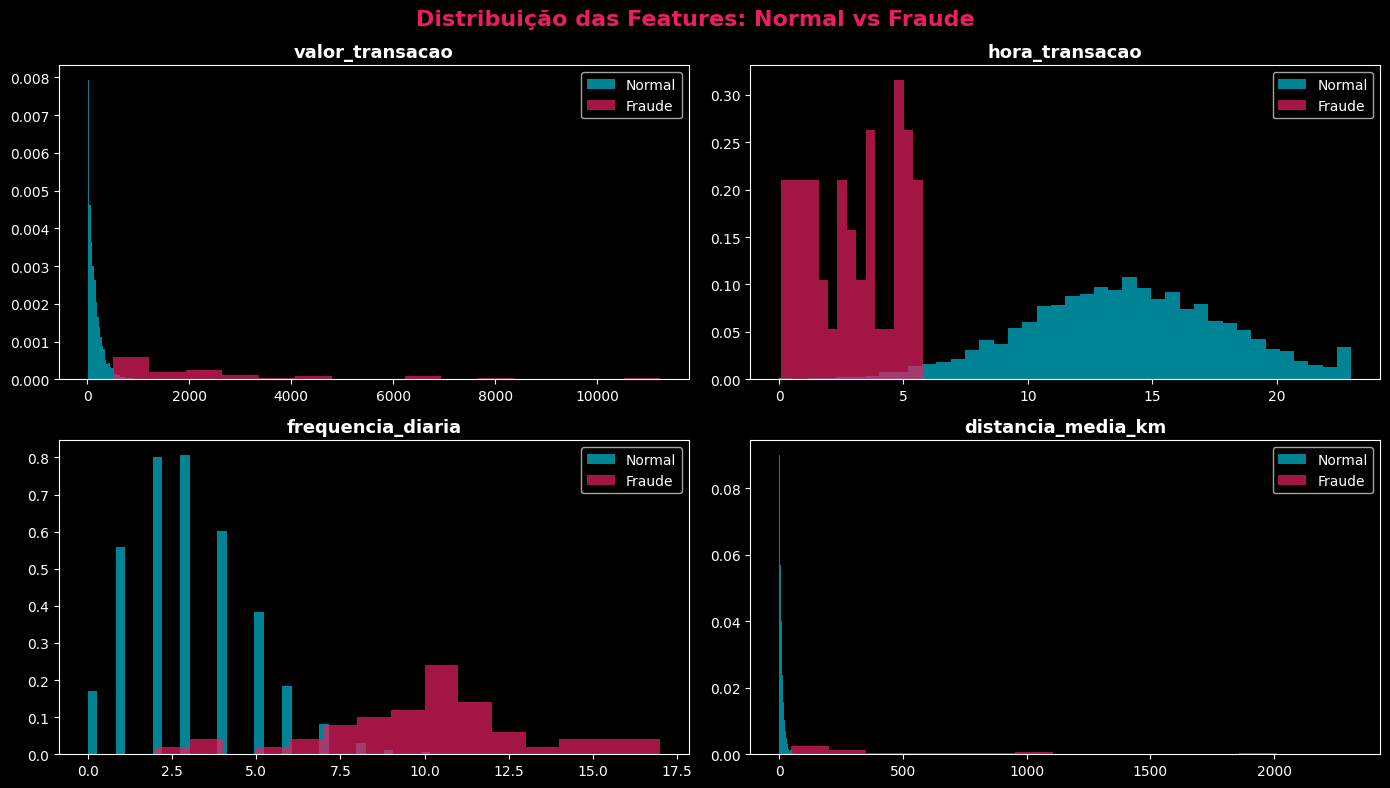

In [4]:
# ═══════════════════════════════════════════════════════════
# Visualizar distribuições: Normal vs Fraude
# ═══════════════════════════════════════════════════════════

features = ['valor_transacao', 'hora_transacao', 'frequencia_diaria', 'distancia_media_km']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[df['fraude'] == 0][feat], bins=40, alpha=0.7, label='Normal', color='#00BCD4', density=True)
    axes[i].hist(df[df['fraude'] == 1][feat], bins=15, alpha=0.7, label='Fraude', color='#E91E63', density=True)
    axes[i].set_title(feat, fontsize=13, fontweight='bold')
    axes[i].legend()

plt.suptitle('Distribuição das Features: Normal vs Fraude', fontsize=16, fontweight='bold', color='#E91E63')
plt.tight_layout()
plt.show()


## 4. Pré-processamento

### Estratégia Fundamental:

> **O autoencoder é treinado APENAS com dados normais.**  
> Ele aprende o padrão de normalidade.  
> Dados que não se encaixam nesse padrão → erro de reconstrução alto → anomalia.

Passos:
1. Separar features e target
2. **Normalizar** com StandardScaler (essencial para redes neurais)
3. Dividir: treino (apenas normais) e teste (normais + fraudes)


In [5]:
# ═══════════════════════════════════════════════════════════
# Separar features e target
# ═══════════════════════════════════════════════════════════

feature_cols = ['valor_transacao', 'hora_transacao', 'frequencia_diaria',
                'distancia_media_km', 'qtd_parcelas', 'tempo_desde_ultima',
                'num_tentativas', 'saldo_conta']

X = df[feature_cols].values
y = df['fraude'].values

print(f"Features: {X.shape}")
print(f"Target:   {y.shape}")
print(f"Normal: {(y == 0).sum()} | Fraude: {(y == 1).sum()}")


Features: (5050, 8)
Target:   (5050,)
Normal: 5000 | Fraude: 50


In [6]:
# ═══════════════════════════════════════════════════════════
# Normalizar os dados (StandardScaler)
# ═══════════════════════════════════════════════════════════

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Média após normalização (deve ser ~0):", X_scaled.mean(axis=0).round(4))
print("Desvio após normalização (deve ser ~1):", X_scaled.std(axis=0).round(4))


Média após normalização (deve ser ~0): [-0.  0. -0.  0. -0. -0. -0.  0.]
Desvio após normalização (deve ser ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# ═══════════════════════════════════════════════════════════
# Separar em TREINO (apenas normais) e TESTE (normais + fraudes)
# ═══════════════════════════════════════════════════════════

# Índices dos normais e fraudes
idx_normal = np.where(y == 0)[0]
idx_fraude = np.where(y == 1)[0]

# Usar 80% dos normais para treino, 20% + todas as fraudes para teste
X_normal = X_scaled[idx_normal]
X_fraude = X_scaled[idx_fraude]

X_train_normal, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

# Teste: normais restantes + todas as fraudes
X_test = np.vstack([X_test_normal, X_fraude])
y_test = np.hstack([np.zeros(len(X_test_normal)), np.ones(len(X_fraude))])

print(f"Treino (apenas normais): {X_train_normal.shape[0]} transações")
print(f"Teste (normais + fraudes): {X_test.shape[0]} transações")
print(f"  - Normais no teste: {(y_test == 0).sum()}")
print(f"  - Fraudes no teste: {(y_test == 1).sum()}")


Treino (apenas normais): 4000 transações
Teste (normais + fraudes): 1050 transações
  - Normais no teste: 1000
  - Fraudes no teste: 50


## 5. Construir o Autoencoder

### Como funciona para detecção de fraude?

```
Transação Normal → Autoencoder → Reconstrução boa (erro baixo) ✅
Transação Fraude → Autoencoder → Reconstrução ruim (erro alto) ❌ → ALERTA!
```

### Arquitetura:

```
Input (8 features)
    ↓
Dense(6, relu)      ← Encoder: comprime
    ↓
Dense(3, relu)      ← Latent Space (gargalo)
    ↓
Dense(6, relu)      ← Decoder: reconstrói
    ↓
Output (8 features) ← Deve ser ≈ Input
```

### Por que funciona?

O autoencoder é treinado **apenas** com transações normais.  
Ele aprende a comprimir e reconstruir **padrões normais**.  
Quando uma fraude passa, o modelo não sabe reconstruí-la → **erro alto**.


In [8]:
# ═══════════════════════════════════════════════════════════
# Definir a arquitetura do Autoencoder
# ═══════════════════════════════════════════════════════════

input_dim = X_train_normal.shape[1]  # 8 features

# Camada de entrada
input_layer = Input(shape=(input_dim,))

# ENCODER: comprime de 8 → 6 → 3
encoded = Dense(6, activation='relu')(input_layer)
encoded = Dense(3, activation='relu')(encoded)   # bottleneck (latent space)

# DECODER: reconstrói de 3 → 6 → 8
decoded = Dense(6, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Montar o modelo
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Resumo da arquitetura
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155 (620.00 B)

 Trainable params: 155 (620.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Treinamento

**Pontos importantes:**
- `X` e `y` do `.fit()` são **iguais** → o autoencoder tenta reconstruir a própria entrada
- Usamos **EarlyStopping** para evitar overfitting
- Treinamos **apenas com dados normais**


In [9]:
# ═══════════════════════════════════════════════════════════
# Treinar o autoencoder (X = y, pois queremos reconstruir a entrada)
# ═══════════════════════════════════════════════════════════

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_normal,       # entrada
    X_train_normal,       # saída esperada = mesma entrada!
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTreinamento finalizado na época {len(history.history['loss'])}")
print(f"Loss final (treino):     {history.history['loss'][-1]:.6f}")
print(f"Loss final (validação):  {history.history['val_loss'][-1]:.6f}")


Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9550 - val_loss: 0.9595
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8567 - val_loss: 0.8081
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7100 - val_loss: 0.6975
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6325 - val_loss: 0.6479
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5985 - val_loss: 0.6278
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5823 - val_loss: 0.6157
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5713 - val_loss: 0.6055
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5619 - val_loss: 0.5955
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5537 - val_loss: 0.5868
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5468 - val_loss: 0.5793
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5407 - val_loss: 0.5732
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━

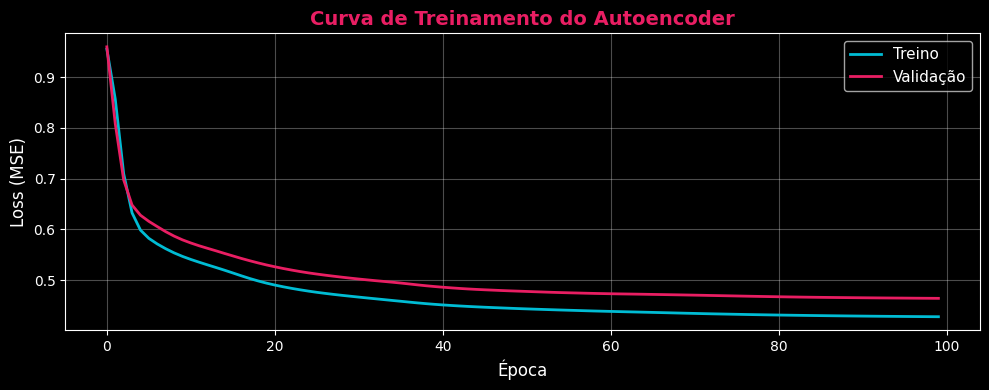

In [10]:
# ═══════════════════════════════════════════════════════════
# Visualizar a curva de treinamento
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Treino', color='#00BCD4', linewidth=2)
ax.plot(history.history['val_loss'], label='Validação', color='#E91E63', linewidth=2)
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Curva de Treinamento do Autoencoder', fontsize=14, fontweight='bold', color='#E91E63')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Calcular Erro de Reconstrução

A ideia central:

| Tipo | Erro de Reconstrução | Resultado |
|------|---------------------|-----------|
| Normal | **Baixo** | Modelo reconhece o padrão |
| Fraude | **Alto** | Modelo não consegue reconstruir |

Calculamos o **MSE por transação** entre a entrada original e a saída reconstruída.


In [11]:
# ═══════════════════════════════════════════════════════════
# Reconstruir os dados de teste e calcular MSE por transação
# ═══════════════════════════════════════════════════════════

# Reconstruir
X_test_pred = autoencoder.predict(X_test, verbose=0)

# Calcular MSE por transação (média do erro quadrático de cada feature)
mse_por_transacao = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

print(f"MSE médio - Normais:  {mse_por_transacao[y_test == 0].mean():.6f}")
print(f"MSE médio - Fraudes:  {mse_por_transacao[y_test == 1].mean():.6f}")
print(f"\nMSE máximo - Normais: {mse_por_transacao[y_test == 0].max():.6f}")
print(f"MSE mínimo - Fraudes: {mse_por_transacao[y_test == 1].min():.6f}")


MSE médio - Normais:  0.427734
MSE médio - Fraudes:  28.980798

MSE máximo - Normais: 3.212381
MSE mínimo - Fraudes: 3.945144


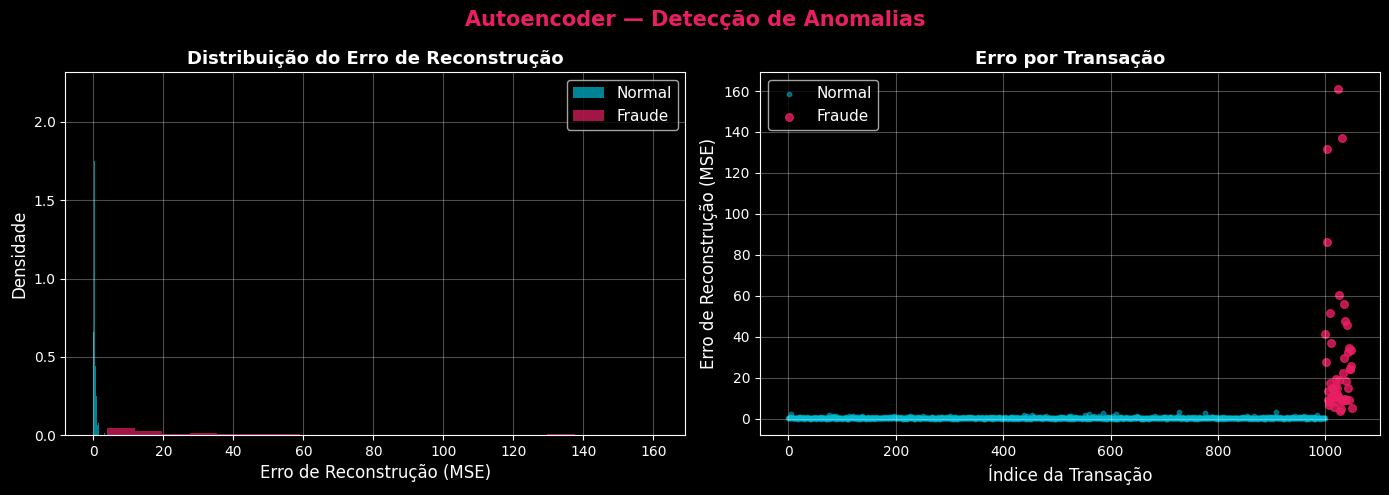

In [12]:
# ═══════════════════════════════════════════════════════════
# Visualizar distribuição do erro: Normal vs Fraude
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(mse_por_transacao[y_test == 0], bins=50, alpha=0.7, label='Normal', color='#00BCD4', density=True)
axes[0].hist(mse_por_transacao[y_test == 1], bins=20, alpha=0.7, label='Fraude', color='#E91E63', density=True)
axes[0].set_xlabel('Erro de Reconstrução (MSE)', fontsize=12)
axes[0].set_ylabel('Densidade', fontsize=12)
axes[0].set_title('Distribuição do Erro de Reconstrução', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Scatter plot
axes[1].scatter(range(len(mse_por_transacao[y_test == 0])),
                mse_por_transacao[y_test == 0], alpha=0.5, s=10, c='#00BCD4', label='Normal')
axes[1].scatter(range(len(mse_por_transacao[y_test == 0]),
                      len(mse_por_transacao[y_test == 0]) + len(mse_por_transacao[y_test == 1])),
                mse_por_transacao[y_test == 1], alpha=0.8, s=30, c='#E91E63', label='Fraude')
axes[1].set_xlabel('Índice da Transação', fontsize=12)
axes[1].set_ylabel('Erro de Reconstrução (MSE)', fontsize=12)
axes[1].set_title('Erro por Transação', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Autoencoder — Detecção de Anomalias', fontsize=15, fontweight='bold', color='#E91E63')
plt.tight_layout()
plt.show()


## 8. Definir Threshold (Limiar de Decisão)

### Como decidir se é fraude ou não?

Precisamos definir um **limiar** (threshold):
- Se `MSE > threshold` → **Fraude** (anomalia)
- Se `MSE <= threshold` → **Normal**

### Estratégias comuns:
1. **Percentil 95-99** do erro no treino (mais conservador)
2. **Média + 2*desvio padrão** do erro no treino
3. **Otimizar F1-score** no conjunto de validação

Vamos usar o **percentil 95** do erro de reconstrução dos dados de treino.


In [13]:
# ═══════════════════════════════════════════════════════════
# Definir threshold usando os dados de TREINO (normais)
# ═══════════════════════════════════════════════════════════

# Reconstruir dados de treino
X_train_pred = autoencoder.predict(X_train_normal, verbose=0)
mse_treino = np.mean(np.power(X_train_normal - X_train_pred, 2), axis=1)

# Threshold = percentil 95 do erro de treino
threshold = np.percentile(mse_treino, 95)

print(f"Erro médio no treino:  {mse_treino.mean():.6f}")
print(f"Erro std no treino:    {mse_treino.std():.6f}")
print(f"Percentil 95:          {threshold:.6f}")
print(f"Percentil 99:          {np.percentile(mse_treino, 99):.6f}")
print(f"\n→ Threshold escolhido: {threshold:.6f}")


Erro médio no treino:  0.433279
Erro std no treino:    0.344218
Percentil 95:          1.022148
Percentil 99:          1.700606

→ Threshold escolhido: 1.022148


In [14]:
# ═══════════════════════════════════════════════════════════
# Classificar usando o threshold
# ═══════════════════════════════════════════════════════════

y_pred = (mse_por_transacao > threshold).astype(int)

print("=" * 50)
print("RESULTADOS DA DETECÇÃO DE FRAUDE")
print("=" * 50)
print(f"\nThreshold: {threshold:.6f}")
print(f"\nTotal de transações no teste: {len(y_test)}")
print(f"Classificadas como fraude: {y_pred.sum()}")
print(f"Fraudes reais: {int(y_test.sum())}")
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))


RESULTADOS DA DETECÇÃO DE FRAUDE

Threshold: 1.022148

Total de transações no teste: 1050
Classificadas como fraude: 95
Fraudes reais: 50

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.98      1000
      Fraude       0.53      1.00      0.69        50

    accuracy                           0.96      1050
   macro avg       0.76      0.98      0.83      1050
weighted avg       0.98      0.96      0.96      1050



## 9. Avaliação Visual

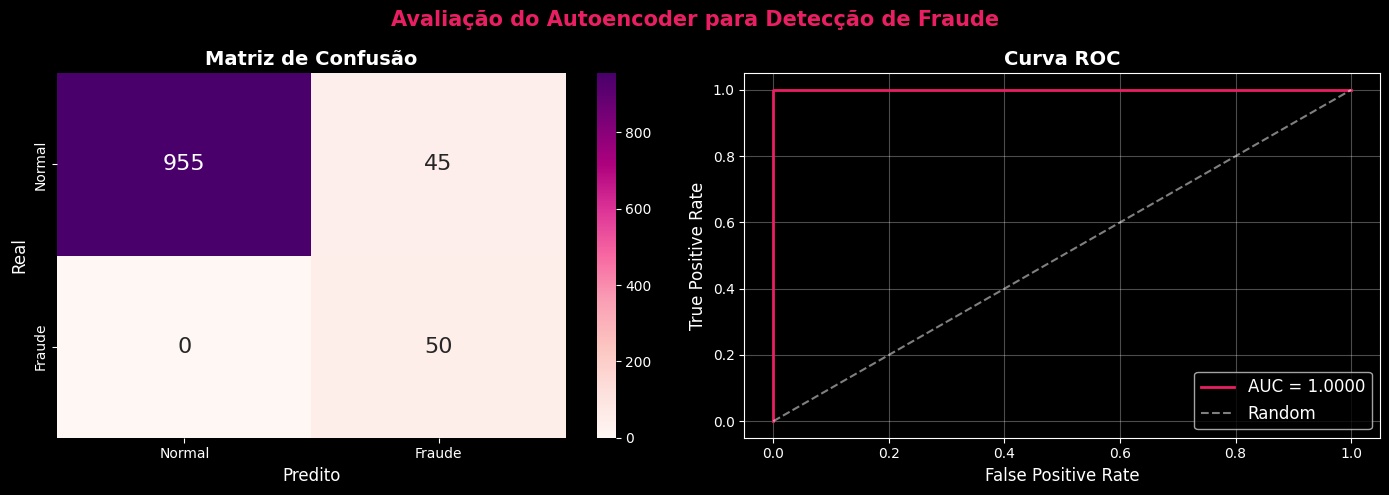


AUC-ROC Score: 1.0000


In [16]:
# ═══════════════════════════════════════════════════════════
# Matriz de Confusão
# ═══════════════════════════════════════════════════════════

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'], ax=axes[0],
            annot_kws={'size': 16})
axes[0].set_xlabel('Predito', fontsize=12)
axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title('Matriz de Confusão', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, mse_por_transacao)
auc_score = roc_auc_score(y_test, mse_por_transacao)

axes[1].plot(fpr, tpr, color='#E91E63', linewidth=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], 'w--', alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Curva ROC', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.suptitle('Avaliação do Autoencoder para Detecção de Fraude',
             fontsize=15, fontweight='bold', color='#E91E63')
plt.tight_layout()
plt.show()

print(f"\nAUC-ROC Score: {auc_score:.4f}")


## 10. Conclusão

### O que aprendemos:

| Conceito | Aplicação |
|----------|-----------|
| Autoencoder treinado só com **normais** | Não precisa de labels de fraude |
| **Erro de reconstrução** como métrica | MSE alto → anomalia |
| **Threshold** define sensibilidade | Percentil 95 do treino |
| Abordagem **não supervisionada** | Detecta fraudes nunca vistas |

### Quando usar esta abordagem:
- Dados com **pouquíssimos exemplos** da classe rara
- **Novos tipos** de anomalia que surgem constantemente
- Cenários onde rotular dados é **caro ou impossível**

### Limitações:
- O threshold é sensível — precisa de ajuste fino
- Falsos positivos podem gerar custo operacional
- Não substitui completamente modelos supervisionados quando há labels suficientes

---

**Próximo passo:** Aplicar autoencoders em **dados de imagem** (Notebook 2).
